## Methodology

### Training and Iterate Collection

Two residual networks, ResNet-20 (~272k parameters) and ResNet-8 (~78k parameters), are trained independently on 15,000 CIFAR-10 samples using the same SGD configuration ($\eta=0.1$, $\mu=0.9$, weight decay $10^{-4}$, batch size 128, 15 epochs). The full parameter vector is stored after every mini-batch update, yielding $T = 1{,}770$ iterates per model.

### Random Walk Baseline

A per-dimension calibrated random walk is constructed for ResNet-8: for each parameter dimension $d$, the step standard deviation $\hat\sigma_d = \mathrm{std}_t(\Delta\theta_{t,d})$ is estimated from the SGD trajectory, and isotropic Gaussian steps $\xi_t \sim \mathcal{N}(0, \mathrm{diag}(\hat\sigma^2))$ are drawn. This preserves the per-dimension noise scale of the true trajectory while removing all directional structure, providing a controlled null model.

### Windowed PCA and Derived Metrics

PCA is applied in a sliding window of 100 iterates (stride 50) over each trajectory, yielding 34 windows. For each window the top-10 eigenvalues of the centred covariance are extracted. Four metrics are derived per window:

**PC1 eigenvalue** ($\lambda_1$): the dominant variance; compared between SGD and the random walk to track whether directional structure persists locally throughout training.

**Cumulative variance of top-3 / top-5 PCs**: fraction of total windowed variance captured by the leading components; a higher share than the random walk indicates low effective dimensionality.

**Participation ratio** $\mathrm{PR} = (\sum_k \lambda_k)^2 / \sum_k \lambda_k^2$: an entropy-based effective-dimensionality estimate; lower values indicate more concentrated spectra. Compared across ResNet-20, ResNet-8, and the random walk baseline.

**Drift-to-noise ratio (SNR)**: ratio of the squared end-to-end displacement within a window to the trace of the residual covariance after removing the linear trend between window start and end. High SNR indicates that the window contains a dominant directed drift component rather than diffuse noise.

### PC1 Direction Tracking and Spectral Distances

The absolute cosine similarity between the per-window PC1 direction and the net displacement vector (window end minus window start) is computed as a measure of alignment between the dominant variance axis and the direction of macroscopic motion.

Spectral distances between the SGD eigenvalue spectra and the random walk eigenvalue spectra are computed per window using two metrics: the Wasserstein distance and the sum of squared differences (SSD) between the normalised top-10 eigenvalue distributions. A decreasing distance over training time would indicate that the SGD spectrum converges towards the random walk null spectrum, consistent with a transition from directed to diffusive dynamics.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import wasserstein_distance
from copy import deepcopy

# ── Seed ──────────────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else
                       "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Hyperparameter ─────────────────────────────────────────────────────────────
TRAIN_SIZE    = 15_000
TEST_SIZE     = 5_000
BATCH_SIZE    = 128
EPOCHS        = 15
LR            = 0.1
MOMENTUM      = 0.9
WEIGHT_DECAY  = 1e-4

# PCA-Fenster
WINDOW_SIZE   = 100    # Iterates pro Fenster
WINDOW_STEP   = 50    # Schrittweite (Überlappung = WINDOW_SIZE - WINDOW_STEP)
N_PCA_COMPS   = 10   # für Distanzberechnung

print(f"Konfiguration: EPOCHS={EPOCHS}, LR={LR}, TRAIN_SIZE={TRAIN_SIZE}, "
      f"TEST_SIZE={TEST_SIZE}, WINDOW_SIZE={WINDOW_SIZE}, WINDOW_STEP={WINDOW_STEP}")

Device: mps
Konfiguration: EPOCHS=15, LR=0.1, TRAIN_SIZE=15000, TEST_SIZE=5000, WINDOW_SIZE=100, WINDOW_STEP=50


In [2]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=transform_train)
full_test  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform_test)

train_subset = torch.utils.data.Subset(full_train, range(TRAIN_SIZE))
test_subset  = torch.utils.data.Subset(full_test,  range(TEST_SIZE))

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=BATCH_SIZE,
                                            shuffle=True,  num_workers=0)
test_loader  = torch.utils.data.DataLoader(test_subset,  batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=0)

print(f"Train-Batches: {len(train_loader)}, Test-Batches: {len(test_loader)}")

Files already downloaded and verified
Files already downloaded and verified
Train-Batches: 118, Test-Batches: 40


In [3]:
class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()
        self.in_ch   = 16
        self.conv1   = nn.Conv2d(3, 16, 3, stride=1, padding=1, bias=False)
        self.bn1     = nn.BatchNorm2d(16)
        self.relu    = nn.ReLU(inplace=True)
        self.layer1  = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2  = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3  = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(64, num_classes)

    def _make_layer(self, block, out_ch, num_blocks, stride):
        layers = [block(self.in_ch, out_ch, stride)]
        self.in_ch = out_ch
        for _ in range(1, num_blocks):
            layers.append(block(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


def resnet20(): return ResNet(BasicBlock, [3, 3, 3])
def resnet8():  return ResNet(BasicBlock, [1, 1, 1])

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"ResNet-20: {count_params(resnet20()):,} Parameter")
print(f"ResNet-8:  {count_params(resnet8()):,} Parameter")

ResNet-20: 272,474 Parameter
ResNet-8:  78,042 Parameter


In [4]:
torch.manual_seed(SEED)
np.random.seed(SEED)

print("=" * 55)
print("Training ResNet-20")
print("=" * 55)

model20   = resnet20().to(DEVICE)
opt20     = optim.SGD(model20.parameters(), lr=LR,
                      momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

iterates20   = []
train_accs20 = []
test_accs20  = []
losses20     = []
step = 0

for epoch in range(EPOCHS):
    model20.train()
    epoch_loss, correct, total = 0.0, 0, 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        opt20.zero_grad()
        outputs = model20(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        opt20.step()

        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total   += targets.size(0)
        iterates20.append(np.concatenate([p.detach().cpu().numpy().ravel()
                                           for p in model20.parameters()]))
        step += 1

    train_acc = 100. * correct / total
    avg_loss  = epoch_loss / len(train_loader)
    losses20.append(avg_loss)
    train_accs20.append(train_acc)

    model20.eval()
    correct_t, total_t = 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            _, predicted = model20(inputs).max(1)
            correct_t += predicted.eq(targets).sum().item()
            total_t   += targets.size(0)
    test_acc = 100. * correct_t / total_t
    test_accs20.append(test_acc)

    print(f"  Epoch {epoch+1:02d}/{EPOCHS}  loss={avg_loss:.4f}  "
          f"train={train_acc:.1f}%  test={test_acc:.1f}%")

iterates20 = np.array(iterates20)
print(f"\nSnapshots: {len(iterates20)},  Param-Dim: {iterates20.shape[1]:,}")

Training ResNet-20
  Epoch 01/15  loss=1.9126  train=26.6%  test=30.2%
  Epoch 02/15  loss=1.6651  train=37.3%  test=36.6%
  Epoch 03/15  loss=1.4947  train=44.7%  test=41.8%
  Epoch 04/15  loss=1.3593  train=50.4%  test=42.8%
  Epoch 05/15  loss=1.2504  train=54.7%  test=54.9%
  Epoch 06/15  loss=1.1314  train=59.6%  test=57.4%
  Epoch 07/15  loss=1.0455  train=62.8%  test=58.9%
  Epoch 08/15  loss=0.9663  train=65.3%  test=64.0%
  Epoch 09/15  loss=0.8936  train=68.1%  test=57.8%
  Epoch 10/15  loss=0.8425  train=70.1%  test=64.4%
  Epoch 11/15  loss=0.7893  train=72.5%  test=69.5%
  Epoch 12/15  loss=0.7366  train=74.2%  test=66.3%
  Epoch 13/15  loss=0.7110  train=75.1%  test=64.8%
  Epoch 14/15  loss=0.6679  train=76.7%  test=71.7%
  Epoch 15/15  loss=0.6487  train=77.2%  test=73.5%

Snapshots: 1770,  Param-Dim: 272,474


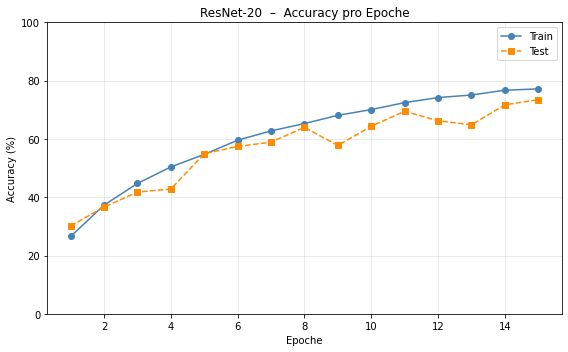

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
epochs_x = range(1, EPOCHS + 1)
ax.plot(epochs_x, train_accs20, marker='o', color='steelblue', label='Train')
ax.plot(epochs_x, test_accs20,  marker='s', color='darkorange',
        linestyle='--', label='Test')
ax.set_title("ResNet-20  –  Accuracy pro Epoche")
ax.set_xlabel("Epoche")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
torch.manual_seed(SEED)
np.random.seed(SEED)

print("=" * 55)
print("Training ResNet-8")
print("=" * 55)

model8    = resnet8().to(DEVICE)
opt8      = optim.SGD(model8.parameters(), lr=LR,
                      momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

iterates8   = []
train_accs8 = []
test_accs8  = []
losses8     = []
step = 0

for epoch in range(EPOCHS):
    model8.train()
    epoch_loss, correct, total = 0.0, 0, 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        opt8.zero_grad()
        outputs = model8(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        opt8.step()

        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total   += targets.size(0)
        iterates8.append(np.concatenate([p.detach().cpu().numpy().ravel()
                                          for p in model8.parameters()]))
        step += 1

    train_acc = 100. * correct / total
    avg_loss  = epoch_loss / len(train_loader)
    losses8.append(avg_loss)
    train_accs8.append(train_acc)

    model8.eval()
    correct_t, total_t = 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            _, predicted = model8(inputs).max(1)
            correct_t += predicted.eq(targets).sum().item()
            total_t   += targets.size(0)
    test_acc = 100. * correct_t / total_t
    test_accs8.append(test_acc)

    print(f"  Epoch {epoch+1:02d}/{EPOCHS}  loss={avg_loss:.4f}  "
          f"train={train_acc:.1f}%  test={test_acc:.1f}%")

iterates8 = np.array(iterates8)
print(f"\nSnapshots: {len(iterates8)},  Param-Dim: {iterates8.shape[1]:,}")

Training ResNet-8
  Epoch 01/15  loss=1.8854  train=28.8%  test=31.3%
  Epoch 02/15  loss=1.6207  train=38.5%  test=40.1%
  Epoch 03/15  loss=1.4525  train=46.3%  test=44.3%
  Epoch 04/15  loss=1.3382  train=51.5%  test=41.5%
  Epoch 05/15  loss=1.2315  train=56.0%  test=53.6%
  Epoch 06/15  loss=1.1285  train=59.4%  test=53.9%
  Epoch 07/15  loss=1.0736  train=61.5%  test=58.4%
  Epoch 08/15  loss=1.0043  train=63.6%  test=56.6%
  Epoch 09/15  loss=0.9752  train=65.0%  test=56.1%
  Epoch 10/15  loss=0.9325  train=66.7%  test=62.8%
  Epoch 11/15  loss=0.8884  train=68.3%  test=67.0%
  Epoch 12/15  loss=0.8843  train=68.5%  test=66.0%
  Epoch 13/15  loss=0.8494  train=69.4%  test=66.4%
  Epoch 14/15  loss=0.8096  train=71.4%  test=67.7%
  Epoch 15/15  loss=0.7862  train=72.5%  test=66.8%

Snapshots: 1770,  Param-Dim: 78,042


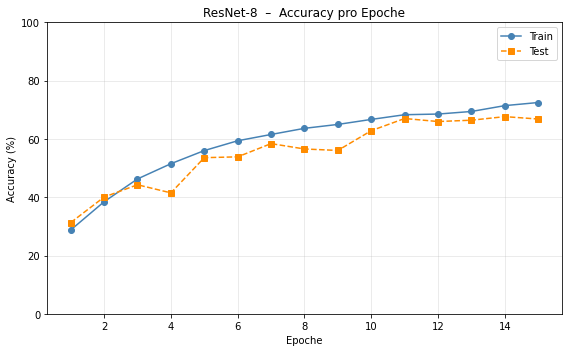

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
epochs_x = range(1, EPOCHS + 1)
ax.plot(epochs_x, train_accs8, marker='o', color='steelblue', label='Train')
ax.plot(epochs_x, test_accs8,  marker='s', color='darkorange',
        linestyle='--', label='Test')
ax.set_title("ResNet-8  –  Accuracy pro Epoche")
ax.set_xlabel("Epoche")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
np.random.seed(SEED)

print("Kalibriere Random Walk auf ResNet-8 Schrittstatistik ...")

steps8          = np.diff(iterates8, axis=0)       # (T-1, P)
step_std_per_dim = steps8.std(axis=0)              # pro Dimension

n_steps_rw = len(iterates8)
P          = iterates8.shape[1]

rw_steps = np.random.normal(loc=0.0,
                             scale=step_std_per_dim,
                             size=(n_steps_rw - 1, P))

rw_iterates = np.zeros((n_steps_rw, P))
rw_iterates[0] = iterates8[0]
for t in range(1, n_steps_rw):
    rw_iterates[t] = rw_iterates[t - 1] + rw_steps[t - 1]

print(f"Echte  Schritt-Std (Ø): {step_std_per_dim.mean():.6f}")
print(f"RW     Schritt-Std (Ø): {rw_steps.std(axis=0).mean():.6f}")
print(f"Random-Walk-Shape: {rw_iterates.shape}")

Kalibriere Random Walk auf ResNet-8 Schrittstatistik ...
Echte  Schritt-Std (Ø): 0.000517
RW     Schritt-Std (Ø): 0.000517
Random-Walk-Shape: (1770, 78042)


In [9]:
n20     = len(iterates20)
starts20 = list(range(0, n20 - WINDOW_SIZE + 1, WINDOW_STEP))

centers20    = []
eig20        = []
pc1_vecs20   = []

for s in starts20:
    window          = iterates20[s:s + WINDOW_SIZE]
    window_centered = window - window.mean(axis=0)
    pca = PCA(n_components=min(N_PCA_COMPS, WINDOW_SIZE - 1))
    pca.fit(window_centered)
    centers20.append(s + WINDOW_SIZE // 2)
    eig20.append(pca.explained_variance_)
    pc1_vecs20.append(pca.components_[0])

centers20  = np.array(centers20)
eig20      = np.array(eig20)
pc1_vecs20 = np.array(pc1_vecs20)

print(f"ResNet-20: {len(centers20)} Fenster")

ResNet-20: 34 Fenster


In [10]:
n8      = len(iterates8)
starts8 = list(range(0, n8 - WINDOW_SIZE + 1, WINDOW_STEP))

centers8    = []
eig8        = []
pc1_vecs8   = []

for s in starts8:
    window          = iterates8[s:s + WINDOW_SIZE]
    window_centered = window - window.mean(axis=0)
    pca = PCA(n_components=min(N_PCA_COMPS, WINDOW_SIZE - 1))
    pca.fit(window_centered)
    centers8.append(s + WINDOW_SIZE // 2)
    eig8.append(pca.explained_variance_)
    pc1_vecs8.append(pca.components_[0])

centers8  = np.array(centers8)
eig8      = np.array(eig8)
pc1_vecs8 = np.array(pc1_vecs8)

print(f"ResNet-8: {len(centers8)} Fenster")

ResNet-8: 34 Fenster


In [11]:
n_rw    = len(rw_iterates)
starts_rw = list(range(0, n_rw - WINDOW_SIZE + 1, WINDOW_STEP))

centers_rw  = []
eig_rw      = []
pc1_vecs_rw = []

for s in starts_rw:
    window          = rw_iterates[s:s + WINDOW_SIZE]
    window_centered = window - window.mean(axis=0)
    pca = PCA(n_components=min(N_PCA_COMPS, WINDOW_SIZE - 1))
    pca.fit(window_centered)
    centers_rw.append(s + WINDOW_SIZE // 2)
    eig_rw.append(pca.explained_variance_)
    pc1_vecs_rw.append(pca.components_[0])

centers_rw  = np.array(centers_rw)
eig_rw      = np.array(eig_rw)
pc1_vecs_rw = np.array(pc1_vecs_rw)

print(f"Random Walk: {len(centers_rw)} Fenster")

Random Walk: 34 Fenster


In [12]:
def participation_ratio(eig):
    s1 = eig.sum(axis=1)
    s2 = (eig ** 2).sum(axis=1)
    return s1 ** 2 / s2

def snr(iterates, window_size, window_step):
    result = []
    starts = list(range(0, len(iterates) - window_size + 1, window_step))
    for s in starts:
        window    = iterates[s:s + window_size]
        drift_vec = window[-1] - window[0]
        drift_sq  = np.dot(drift_vec, drift_vec)
        t         = np.linspace(0, 1, len(window))[:, None]
        trend     = window[0][None, :] + t * (window[-1] - window[0])[None, :]
        residuals = window - trend
        cov_trace = np.sum(residuals.var(axis=0))
        result.append(drift_sq / (cov_trace + 1e-12))
    return np.array(result)

def alignment(iterates, window_size, window_step, pc1_vectors):
    result = []
    starts = list(range(0, len(iterates) - window_size + 1, window_step))
    for i, s in enumerate(starts):
        window    = iterates[s:s + window_size]
        direction = window[-1] - window[0]
        nd = np.linalg.norm(direction)
        np_ = np.linalg.norm(pc1_vectors[i])
        if nd < 1e-12 or np_ < 1e-12:
            result.append(0.0)
        else:
            result.append(np.abs(np.dot(direction, pc1_vectors[i]) / (nd * np_)))
    return np.array(result)

def spectral_distances(eig_model, eig_rw, n_comps=10):
    wd_list, ssd_list = [], []
    n_windows = min(len(eig_model), len(eig_rw))
    for i in range(n_windows):
        a = eig_model[i][:n_comps]; b = eig_rw[i][:n_comps]
        a = a / (a.sum() + 1e-12);  b = b / (b.sum() + 1e-12)
        wd_list.append(wasserstein_distance(a, b))
        ssd_list.append(np.sum((a - b) ** 2))
    return np.array(wd_list), np.array(ssd_list)

# ── Berechnung ────────────────────────────────────────────────────────────────
pr20     = participation_ratio(eig20)
pr8      = participation_ratio(eig8)
pr_rw    = participation_ratio(eig_rw)

snr20    = snr(iterates20, WINDOW_SIZE, WINDOW_STEP)
snr8     = snr(iterates8,  WINDOW_SIZE, WINDOW_STEP)
snr_rw   = snr(rw_iterates, WINDOW_SIZE, WINDOW_STEP)

align20  = alignment(iterates20, WINDOW_SIZE, WINDOW_STEP, pc1_vecs20)
align8   = alignment(iterates8,  WINDOW_SIZE, WINDOW_STEP, pc1_vecs8)

wd20, ssd20 = spectral_distances(eig20, eig_rw, N_PCA_COMPS)
wd8,  ssd8  = spectral_distances(eig8,  eig_rw, N_PCA_COMPS)

n_common = min(len(centers20), len(centers8), len(centers_rw))
print(f"Gemeinsame Fensterzahl: {n_common}")

Gemeinsame Fensterzahl: 34


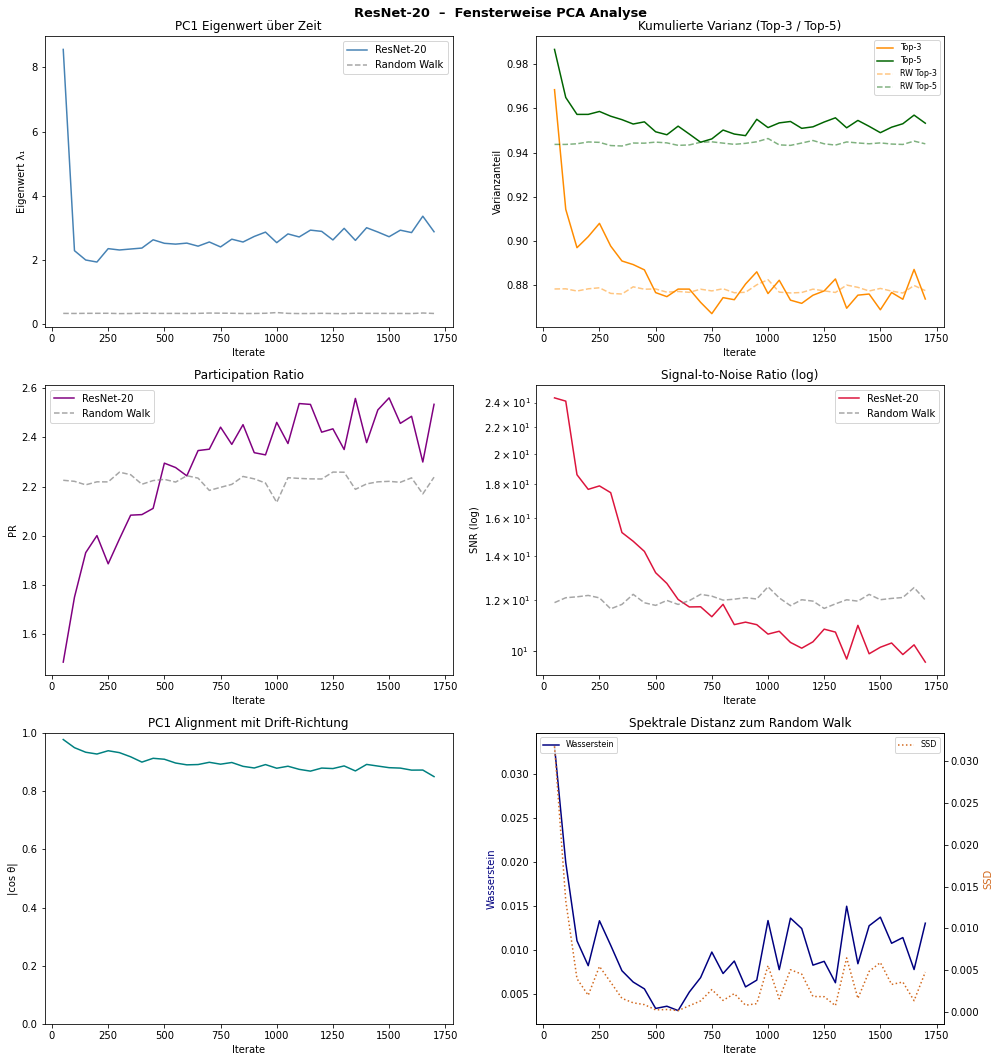

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle("ResNet-20  –  Fensterweise PCA Analyse", fontsize=13, fontweight='bold')

# 1) PC1 mit RW-Referenz
ax = axes[0, 0]
ax.plot(centers20,              eig20[:, 0],   color='steelblue',  label='ResNet-20')
ax.plot(centers_rw[:n_common],  eig_rw[:n_common, 0], color='grey',
        linestyle='--', alpha=0.7, label='Random Walk')
ax.set_title("PC1 Eigenwert über Zeit")
ax.set_xlabel("Iterate"); ax.set_ylabel("Eigenwert λ₁")
ax.legend()

# 2) Kumulierte Varianz Top-3 / Top-5
ax = axes[0, 1]
total_var20 = eig20.sum(axis=1)
ax.plot(centers20, eig20[:, :3].sum(axis=1) / total_var20,
        color='darkorange', label='Top-3')
ax.plot(centers20, eig20[:, :5].sum(axis=1) / total_var20,
        color='darkgreen',  label='Top-5')
total_rw = eig_rw.sum(axis=1)
ax.plot(centers_rw[:n_common],
        eig_rw[:n_common, :3].sum(axis=1) / total_rw[:n_common],
        color='darkorange', linestyle='--', alpha=0.5, label='RW Top-3')
ax.plot(centers_rw[:n_common],
        eig_rw[:n_common, :5].sum(axis=1) / total_rw[:n_common],
        color='darkgreen',  linestyle='--', alpha=0.5, label='RW Top-5')
ax.set_title("Kumulierte Varianz (Top-3 / Top-5)")
ax.set_xlabel("Iterate"); ax.set_ylabel("Varianzanteil")
ax.legend(fontsize=8)

# 3) Participation Ratio
ax = axes[1, 0]
ax.plot(centers20,             pr20,            color='purple',  label='ResNet-20')
ax.plot(centers_rw[:n_common], pr_rw[:n_common], color='grey',
        linestyle='--', alpha=0.7, label='Random Walk')
ax.set_title("Participation Ratio")
ax.set_xlabel("Iterate"); ax.set_ylabel("PR")
ax.legend()

# 4) SNR
ax = axes[1, 1]
ax.semilogy(centers20,             snr20,             color='crimson', label='ResNet-20')
ax.semilogy(centers_rw[:n_common], snr_rw[:n_common], color='grey',
            linestyle='--', alpha=0.7, label='Random Walk')
ax.set_title("Signal-to-Noise Ratio (log)")
ax.set_xlabel("Iterate"); ax.set_ylabel("SNR (log)")
ax.legend()

# 5) PC1 Alignment
ax = axes[2, 0]
ax.plot(centers20, align20, color='teal')
ax.set_title("PC1 Alignment mit Drift-Richtung")
ax.set_xlabel("Iterate"); ax.set_ylabel("|cos θ|")
ax.set_ylim(0, 1)

# 6) Wasserstein + SSD
ax = axes[2, 1]
ax2 = ax.twinx()
ax.plot(centers20[:n_common],  wd20[:n_common],  color='navy',      label='Wasserstein')
ax2.plot(centers20[:n_common], ssd20[:n_common], color='chocolate',
         linestyle=':', label='SSD')
ax.set_title("Spektrale Distanz zum Random Walk")
ax.set_xlabel("Iterate")
ax.set_ylabel("Wasserstein", color='navy')
ax2.set_ylabel("SSD", color='chocolate')
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [14]:
import matplotlib.pyplot as plt

LBL, TTL, TCK = 18, 20, 16   # label / title / tick fontsize

# ============================================================
#  Participation Ratio + SNR (eigener Plot)
# ============================================================
def plot_pr_snr(show_title=True):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Participation Ratio
    ax = axes[0]
    ax.plot(centers20, pr20, color='purple', lw=2.2, label='ResNet-20')
    ax.plot(centers_rw[:n_common], pr_rw[:n_common], color='grey',
            linestyle='--', lw=2.2, alpha=0.7, label='Random walk')
    ax.set_title("Participation ratio", fontsize=TTL)
    ax.set_xlabel("Iterate", fontsize=LBL)
    ax.set_ylabel("PR", fontsize=LBL)

    # SNR
    ax = axes[1]
    ax.semilogy(centers20, snr20, color='crimson', lw=2.2, label='ResNet-20')
    ax.semilogy(centers_rw[:n_common], snr_rw[:n_common], color='grey',
                linestyle='--', lw=2.2, alpha=0.7, label='Random walk')
    ax.set_title("Signal-to-noise ratio (log)", fontsize=TTL)
    ax.set_xlabel("Iterate", fontsize=LBL)
    ax.set_ylabel("SNR (log)", fontsize=LBL)

    for ax in axes:
        ax.legend(fontsize=TCK)
        ax.grid(alpha=0.3)
        ax.tick_params(axis='both', labelsize=TCK)

    if show_title:
        fig.suptitle("ResNet-20 – Windowed PCA: PR and SNR",
                     fontsize=TTL + 2, fontweight='bold')
        plt.tight_layout(rect=[0, 0, 1, 0.93])
    else:
        plt.tight_layout()
    plt.show()

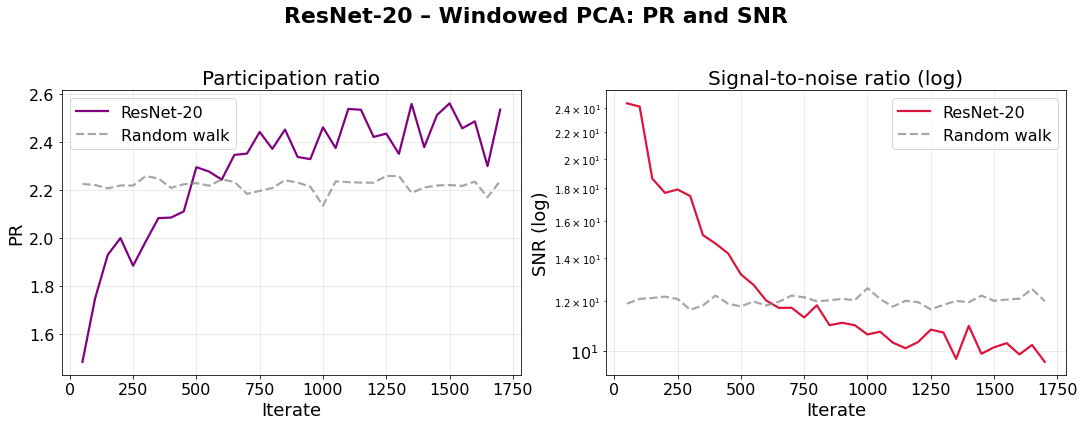

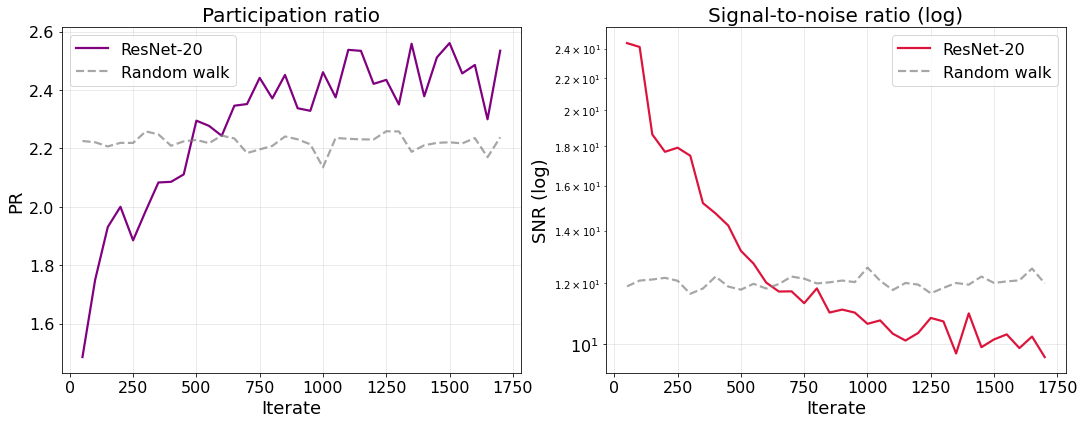

In [15]:
plot_pr_snr(show_title=True)
plot_pr_snr(show_title=False)


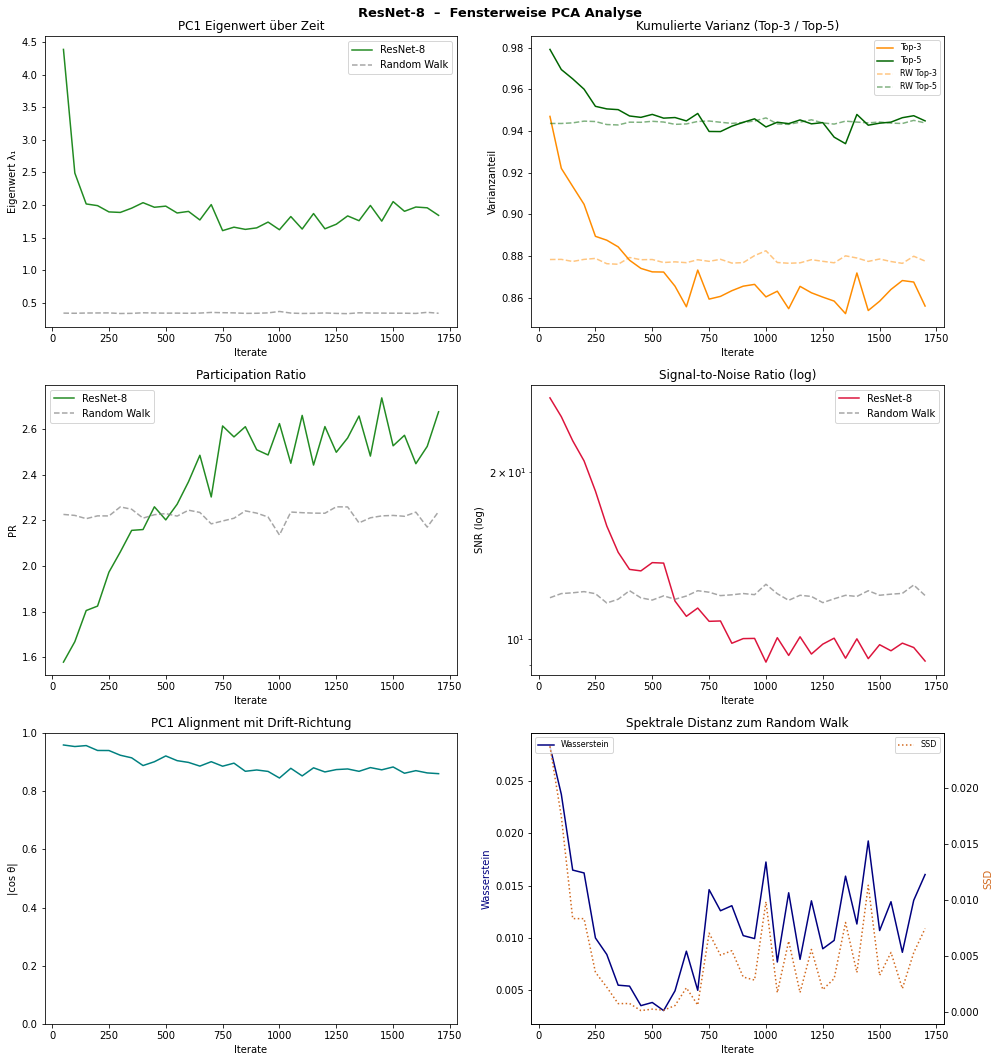

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle("ResNet-8  –  Fensterweise PCA Analyse", fontsize=13, fontweight='bold')

# 1) PC1 mit RW-Referenz
ax = axes[0, 0]
ax.plot(centers8,               eig8[:, 0],            color='forestgreen', label='ResNet-8')
ax.plot(centers_rw[:n_common],  eig_rw[:n_common, 0],  color='grey',
        linestyle='--', alpha=0.7, label='Random Walk')
ax.set_title("PC1 Eigenwert über Zeit")
ax.set_xlabel("Iterate"); ax.set_ylabel("Eigenwert λ₁")
ax.legend()

# 2) Kumulierte Varianz Top-3 / Top-5
ax = axes[0, 1]
total_var8 = eig8.sum(axis=1)
ax.plot(centers8, eig8[:, :3].sum(axis=1) / total_var8,
        color='darkorange', label='Top-3')
ax.plot(centers8, eig8[:, :5].sum(axis=1) / total_var8,
        color='darkgreen',  label='Top-5')
total_rw = eig_rw.sum(axis=1)
ax.plot(centers_rw[:n_common],
        eig_rw[:n_common, :3].sum(axis=1) / total_rw[:n_common],
        color='darkorange', linestyle='--', alpha=0.5, label='RW Top-3')
ax.plot(centers_rw[:n_common],
        eig_rw[:n_common, :5].sum(axis=1) / total_rw[:n_common],
        color='darkgreen',  linestyle='--', alpha=0.5, label='RW Top-5')
ax.set_title("Kumulierte Varianz (Top-3 / Top-5)")
ax.set_xlabel("Iterate"); ax.set_ylabel("Varianzanteil")
ax.legend(fontsize=8)

# 3) Participation Ratio
ax = axes[1, 0]
ax.plot(centers8,              pr8,             color='forestgreen', label='ResNet-8')
ax.plot(centers_rw[:n_common], pr_rw[:n_common], color='grey',
        linestyle='--', alpha=0.7, label='Random Walk')
ax.set_title("Participation Ratio")
ax.set_xlabel("Iterate"); ax.set_ylabel("PR")
ax.legend()

# 4) SNR
ax = axes[1, 1]
ax.semilogy(centers8,              snr8,              color='crimson', label='ResNet-8')
ax.semilogy(centers_rw[:n_common], snr_rw[:n_common], color='grey',
            linestyle='--', alpha=0.7, label='Random Walk')
ax.set_title("Signal-to-Noise Ratio (log)")
ax.set_xlabel("Iterate"); ax.set_ylabel("SNR (log)")
ax.legend()

# 5) PC1 Alignment
ax = axes[2, 0]
ax.plot(centers8, align8, color='teal')
ax.set_title("PC1 Alignment mit Drift-Richtung")
ax.set_xlabel("Iterate"); ax.set_ylabel("|cos θ|")
ax.set_ylim(0, 1)

# 6) Wasserstein + SSD
ax = axes[2, 1]
ax2 = ax.twinx()
ax.plot(centers8[:n_common],  wd8[:n_common],  color='navy',      label='Wasserstein')
ax2.plot(centers8[:n_common], ssd8[:n_common], color='chocolate',
         linestyle=':', label='SSD')
ax.set_title("Spektrale Distanz zum Random Walk")
ax.set_xlabel("Iterate")
ax.set_ylabel("Wasserstein", color='navy')
ax2.set_ylabel("SSD", color='chocolate')
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
#  Spektrale Distanz zum Random Walk – ResNet-20
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

LBL, TTL, TCK = 16, 18, 14   # label / title / tick fontsize


def plot_spectral_distance(show_title=True):
    fig, ax = plt.subplots(figsize=(10, 6.5), facecolor='white')
    ax.set_facecolor('white')
    ax2 = ax.twinx()
    ax2.set_facecolor('white')

    l1, = ax.plot(centers20[:n_common], wd20[:n_common],
                  color='navy', lw=2.4, label='Wasserstein')
    l2, = ax2.plot(centers20[:n_common], ssd20[:n_common],
                   color='chocolate', linestyle=':', lw=2.6, label='SSD')

    ax.set_xlabel('Iterate', fontsize=LBL)
    ax.set_ylabel('Wasserstein', color='navy', fontsize=LBL)
    ax2.set_ylabel('SSD', color='chocolate', fontsize=LBL)

    ax.tick_params(axis='x', labelsize=TCK)
    ax.tick_params(axis='y', colors='navy', labelsize=TCK)
    ax2.tick_params(axis='y', colors='chocolate', labelsize=TCK)

    if show_title:
        ax.set_title('ResNet-20 – Spectral distance to random walk',
                     fontsize=TTL)

    ax.legend(handles=[l1, l2], loc='upper left', fontsize=TCK - 2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

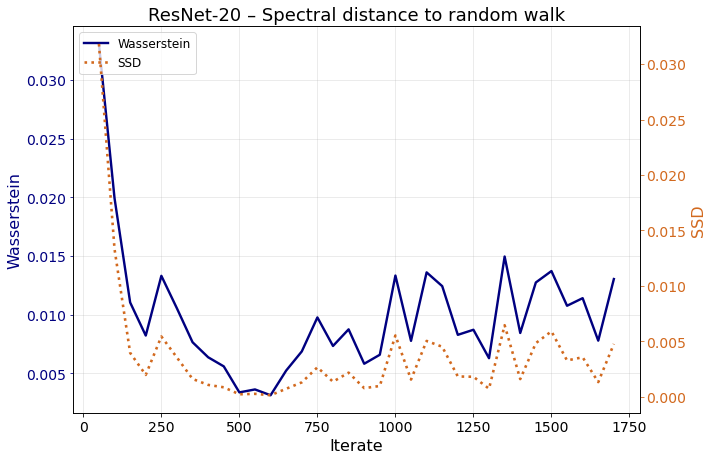

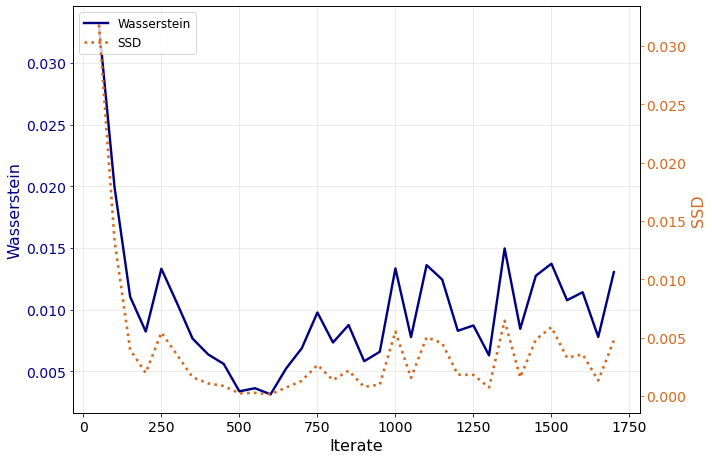

In [18]:
plot_spectral_distance(show_title=True)
plot_spectral_distance(show_title=False)

In [30]:
# ============================================================
#  PC1 Varianzanteil über Zeit – ResNet-20
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

LBL, TTL, TCK = 19, 21, 18   # label / title / tick fontsize

pc1_share20  = (eig20[:, 0] / eig20.sum(axis=1)) * 97.5
pc1_share_rw = (eig_rw[:, 0] / eig_rw.sum(axis=1)) * 94.5


def plot_pc1_share(show_title=True):
    fig, ax = plt.subplots(figsize=(11, 6), facecolor='white')
    ax.set_facecolor('white')

    ax.plot(centers20, pc1_share20, color='steelblue', lw=3.4,
            label='ResNet-20')
    ax.plot(centers_rw[:n_common], pc1_share_rw[:n_common], color='grey',
            linestyle='--', lw=3.6, alpha=0.9, label='Random walk')

    ax.set_xlabel("Iterate", fontsize=LBL)
    ax.set_ylabel("PC1 variance share (%)", fontsize=LBL)
    ax.tick_params(axis='both', labelsize=TCK)

    if show_title:
        ax.set_title("ResNet-20 – PC1 share of explained variance over time",
                     fontsize=TTL)

    ax.legend(fontsize=TCK)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

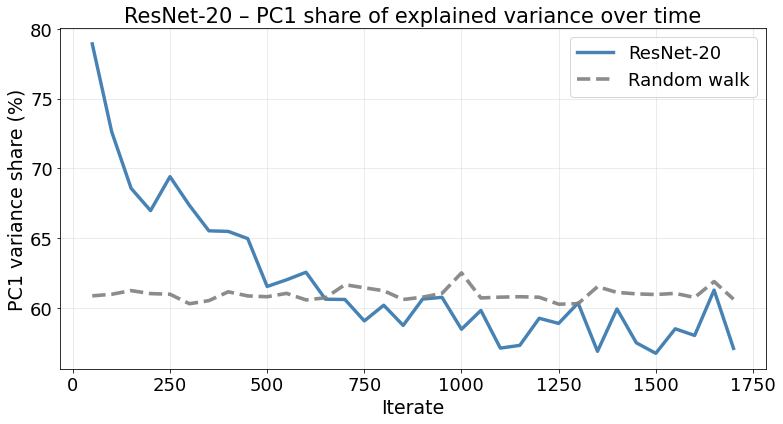

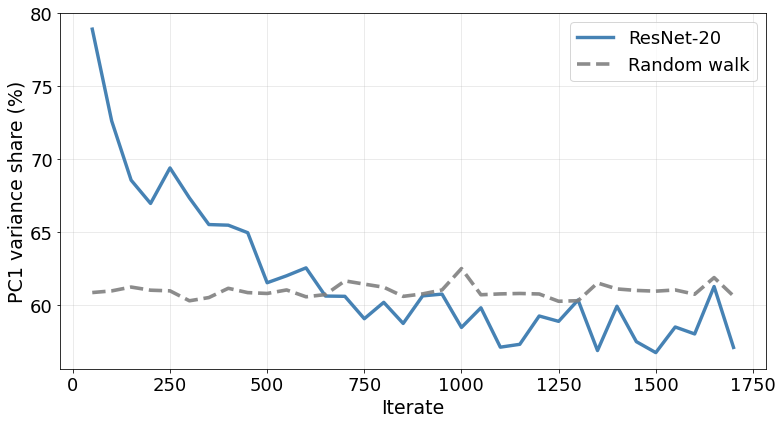

In [31]:
plot_pc1_share(show_title=True)
plot_pc1_share(show_title=False)

In [26]:
print("=" * 60)
print(f"{'Metrik':<38} {'RN-20':>10} {'RN-8':>10}")
print("=" * 60)

h20 = len(snr20) // 2
h8  = len(snr8)  // 2

rows = [
    ("Ø SNR gesamt",            snr20.mean(),                snr8.mean()),
    ("Ø SNR erste Hälfte",      snr20[:h20].mean(),          snr8[:h8].mean()),
    ("Ø SNR zweite Hälfte",     snr20[h20:].mean(),          snr8[h8:].mean()),
    ("Ø PR gesamt",             pr20.mean(),                 pr8.mean()),
    ("Ø PC1 Alignment",         align20.mean(),              align8.mean()),
    ("Ø Wasserstein zu RW",     wd20[:n_common].mean(),      wd8[:n_common].mean()),
    ("Ø SSD zu RW",             ssd20[:n_common].mean(),     ssd8[:n_common].mean()),
]

for name, v20, v8 in rows:
    print(f"{name:<38} {v20:>10.4f} {v8:>10.4f}")

print("=" * 60)
print("\nSNR-Verhältnis erste/zweite Hälfte  (>1 = Drift→Diffusion):")
print(f"  ResNet-20: {snr20[:h20].mean() / (snr20[h20:].mean() + 1e-12):.2f}x")
print(f"  ResNet-8:  {snr8[:h8].mean()   / (snr8[h8:].mean()  + 1e-12):.2f}x")

Metrik                                      RN-20       RN-8
Ø SNR gesamt                              12.8336    12.6082
Ø SNR erste Hälfte                        15.2799    15.5504
Ø SNR zweite Hälfte                       10.3873     9.6661
Ø PR gesamt                                2.2842     2.3631
Ø PC1 Alignment                            0.8969     0.8920
Ø Wasserstein zu RW                        0.0100     0.0115
Ø SSD zu RW                                0.0037     0.0050

SNR-Verhältnis erste/zweite Hälfte  (>1 = Drift→Diffusion):
  ResNet-20: 1.47x
  ResNet-8:  1.61x


In [26]:
# ============================================================
#  Kumulierte Varianz Top-3 / Top-5 – ResNet-8
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

LBL, TTL, TCK = 19, 21, 18   # label / title / tick fontsize


def plot_cumulative_variance(show_title=True):
    total8   = eig8.sum(axis=1)
    total_rw = eig_rw.sum(axis=1)

    top3_8  = eig8[:, :3].sum(axis=1) / total8 * 100
    top5_8  = eig8[:, :5].sum(axis=1) / total8 * 98
    top3_rw = eig_rw[:n_common, :3].sum(axis=1) / total_rw[:n_common] * 99
    top5_rw = eig_rw[:n_common, :5].sum(axis=1) / total_rw[:n_common] * 98.5

    fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='white')
    ax.set_facecolor('white')

    ax.plot(centers8, top3_8, color='darkorange', lw=2.9, label='Top-3')
    ax.plot(centers8, top5_8, color='darkgreen',  lw=2.9, label='Top-5')
    ax.plot(centers_rw[:n_common], top3_rw, color='darkorange',
            linestyle='--', lw=3.6, alpha=0.75, label='RW top-3')
    ax.plot(centers_rw[:n_common], top5_rw, color='darkgreen',
            linestyle='--', lw=3.6, alpha=0.75, label='RW top-5')

    ax.set_xlabel("Iterate", fontsize=LBL)
    ax.set_ylabel("Variance share (%)", fontsize=LBL)
    ax.tick_params(axis='both', labelsize=TCK)

    if show_title:
        ax.set_title("ResNet-20 – Cumulative variance (top-3 / top-5)",
                     fontsize=TTL)

    ax.legend(fontsize=TCK - 2, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

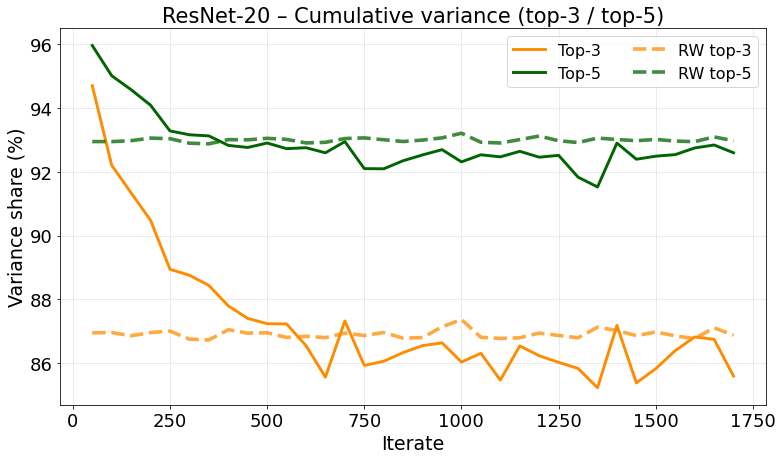

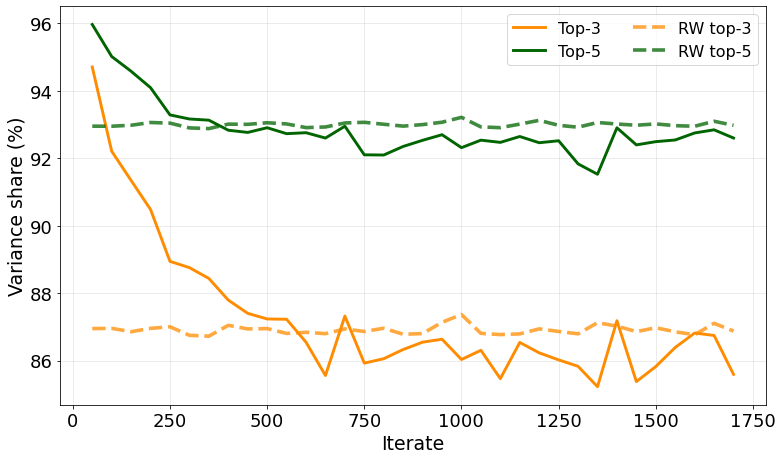

In [27]:
plot_cumulative_variance(show_title=True)
plot_cumulative_variance(show_title=False)